In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the raw dataset
DATA_PATH = "../data/application_train.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")

Matplotlib is building the font cache; this may take a moment.


Dataset shape: (307511, 122)


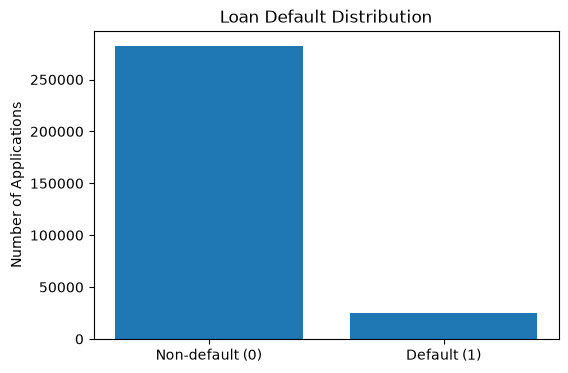

In [ ]:
#Target distribution ,We already know the target is imbalanced. Let's visualize it.

target_counts = df["TARGET"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Non-default (0)", "Default (1)"], target_counts.values)

plt.title("Loan Default Distribution")
plt.ylabel("Number of Applications")

plt.show()

In [3]:
default_rate = df["TARGET"].mean()

print(f"Default rate: {default_rate:.2%}")
print(f"Non-default rate: {1 - default_rate:.2%}")

Default rate: 8.07%
Non-default rate: 91.93%


In [4]:
#Missing-value overview

#Rather than examining all 122 columns manually, let's identify the most problematic ones.

missing_summary = (
    df.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .to_frame("missing_percentage")
)

missing_summary.head(20)

,missing_percentage
COMMONAREA_MEDI,69.872297
COMMONAREA_AVG,69.872297
COMMONAREA_MODE,69.872297
NONLIVINGAPARTMENTS_MODE,69.432963
NONLIVINGAPARTMENTS_AVG,69.432963
NONLIVINGAPARTMENTS_MEDI,69.432963
FONDKAPREMONT_MODE,68.386172
LIVINGAPARTMENTS_MODE,68.354953
LIVINGAPARTMENTS_AVG,68.354953
LIVINGAPARTMENTS_MEDI,68.354953


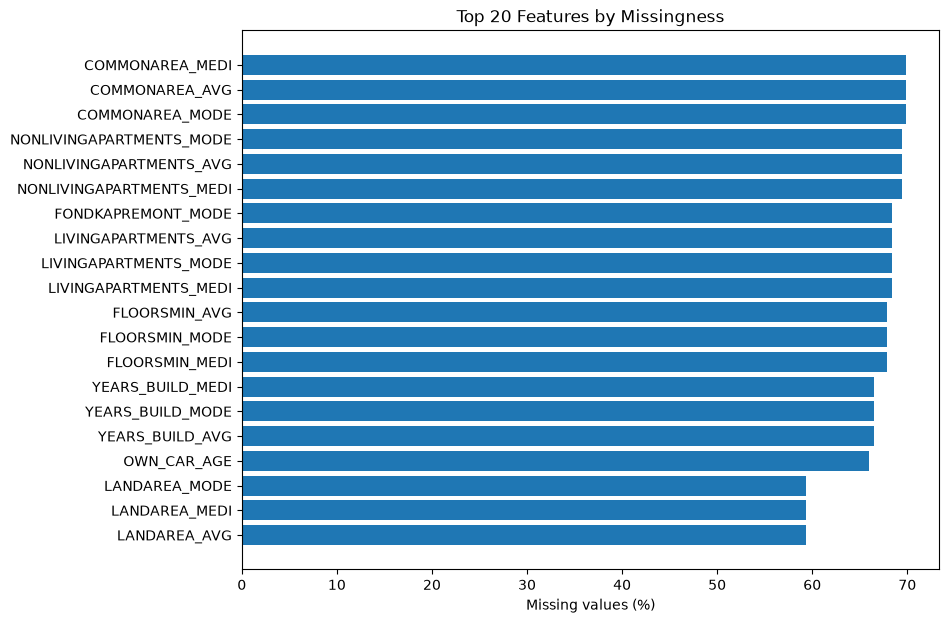

In [ ]:
#Visualise the top 20 features with the highest missing values.

top_missing = missing_summary.head(20).sort_values("missing_percentage")

plt.figure(figsize=(9, 7))

plt.barh(
    top_missing.index,
    top_missing["missing_percentage"]
)

plt.xlabel("Missing values (%)")
plt.title("Top 20 Features by Missingness")

plt.show()

In [6]:
#Numerical feature distributions

#We have 100+ numerical columns, so don't plot all of them.

important_numeric = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS"
]

df[important_numeric].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
CNT_FAM_MEMBERS,307509.0,2.152665,0.910682,1.0,2.0,2.0,3.0,20.0


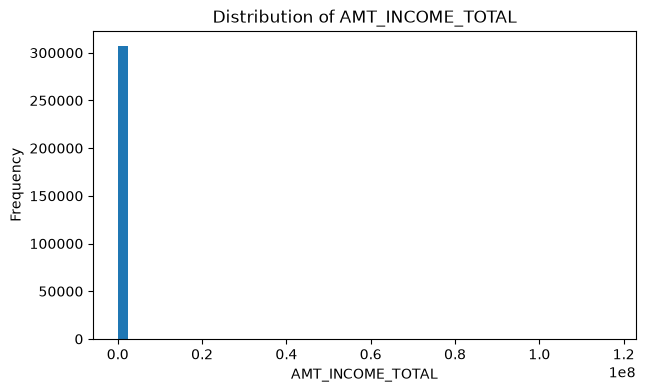

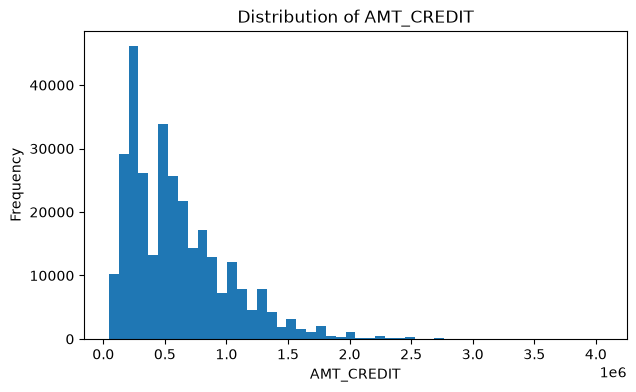

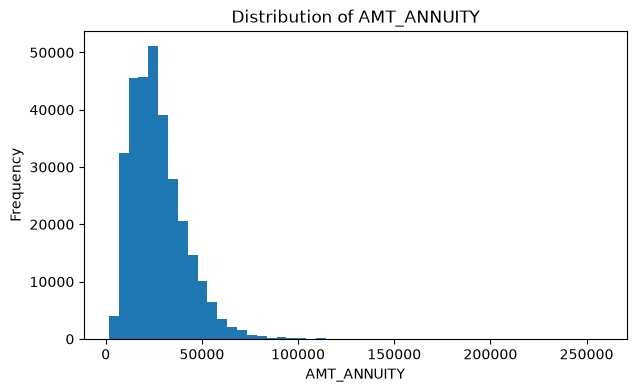

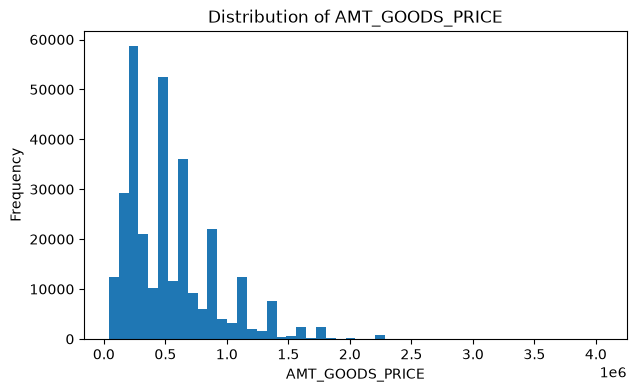

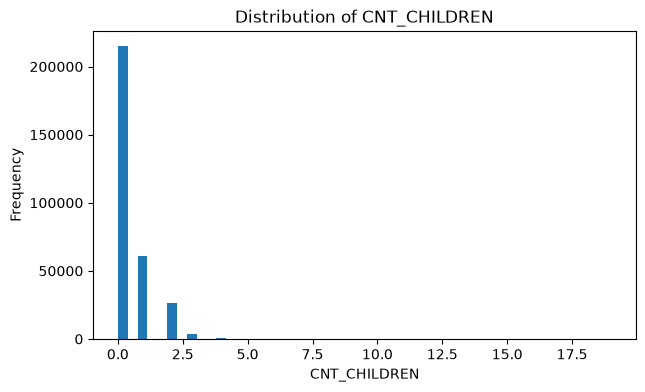

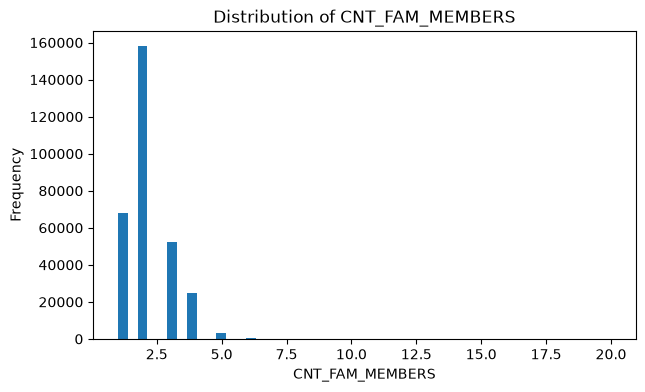

In [7]:
for column in important_numeric:
    plt.figure(figsize=(7, 4))
    
    plt.hist(
        df[column].dropna(),
        bins=50
    )
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    
    plt.show()

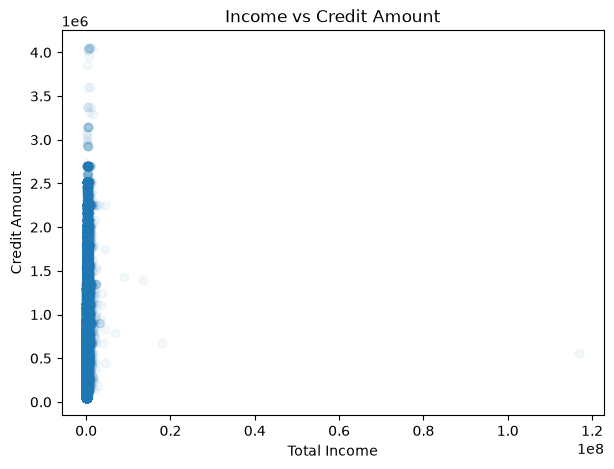

In [8]:
#Income and credit relationship

#This is particularly useful for credit-risk modelling.

plt.figure(figsize=(7, 5))

plt.scatter(
    df["AMT_INCOME_TOTAL"],
    df["AMT_CREDIT"],
    alpha=0.05
)

plt.xlabel("Total Income")
plt.ylabel("Credit Amount")
plt.title("Income vs Credit Amount")

plt.show()



In [9]:
#Default rate across important categorical features

categorical_to_check = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE"
]

In [ ]:
#Does default behaviour differ across categories?

for column in categorical_to_check:
    
    print(f"\n===== {column} =====")
    
    default_by_category = (
        df.groupby(column)["TARGET"]
        .agg(["count", "mean"])
        .sort_values("mean", ascending=False)
    )
    
    default_by_category["default_rate_%"] = (
        default_by_category["mean"] * 100
    )
    
    display(default_by_category)


===== NAME_CONTRACT_TYPE =====


,count,mean,default_rate_%
NAME_CONTRACT_TYPE,,,
Cash loans,278232,0.083459,8.345913
Revolving loans,29279,0.054783,5.478329



===== CODE_GENDER =====


,count,mean,default_rate_%
CODE_GENDER,,,
M,105059,0.101419,10.141920
F,202448,0.069993,6.999328
XNA,4,0.000000,0.000000



===== NAME_EDUCATION_TYPE =====


,count,mean,default_rate_%
NAME_EDUCATION_TYPE,,,
Lower secondary,3816,0.109277,10.927673
Secondary / secondary special,218391,0.089399,8.939929
Incomplete higher,10277,0.084850,8.484966
Higher education,74863,0.053551,5.355115
Academic degree,164,0.018293,1.829268



===== NAME_FAMILY_STATUS =====


,count,mean,default_rate_%
NAME_FAMILY_STATUS,,,
Civil marriage,29775,0.099446,9.944584
Single / not married,45444,0.098077,9.807675
Separated,19770,0.081942,8.194234
Married,196432,0.075599,7.559868
Widow,16088,0.058242,5.824217
Unknown,2,0.000000,0.000000



===== NAME_HOUSING_TYPE =====


,count,mean,default_rate_%
NAME_HOUSING_TYPE,,,
Rented apartment,4881,0.123131,12.313051
With parents,14840,0.116981,11.698113
Municipal apartment,11183,0.085397,8.539748
Co-op apartment,1122,0.079323,7.932264
House / apartment,272868,0.077957,7.795711
Office apartment,2617,0.065724,6.572411


In [11]:
#Default rate by external credit scores

external_scores = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

df[external_scores].describe().T

,count,mean,std,min,25%,50%,75%,max
EXT_SOURCE_1,134133.0,0.502130,0.211062,1.456813e-02,0.334007,0.505998,0.675053,0.962693
EXT_SOURCE_2,306851.0,0.514393,0.191060,8.173617e-08,0.392457,0.565961,0.663617,0.855000
EXT_SOURCE_3,246546.0,0.510853,0.194844,5.272652e-04,0.370650,0.535276,0.669057,0.896010


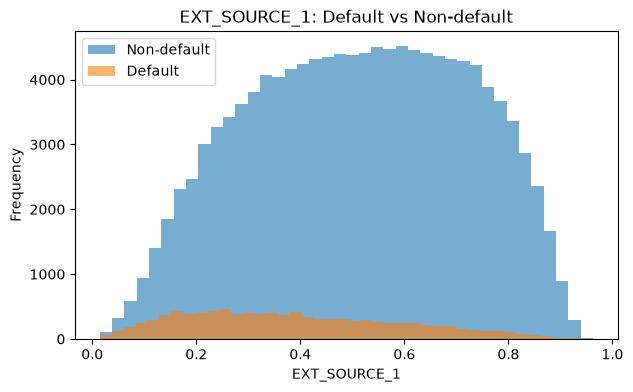

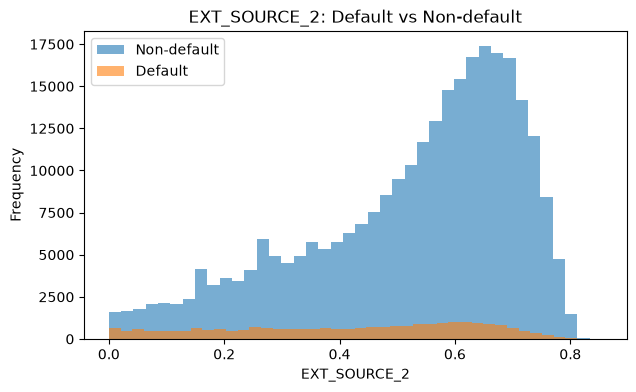

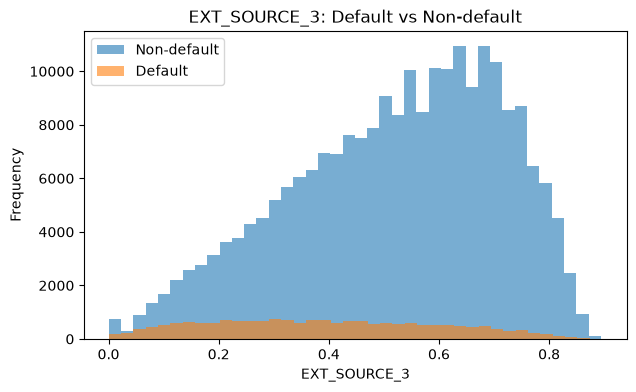

In [12]:
for column in external_scores:
    
    plt.figure(figsize=(7, 4))
    
    plt.hist(
        df.loc[df["TARGET"] == 0, column].dropna(),
        bins=40,
        alpha=0.6,
        label="Non-default"
    )
    
    plt.hist(
        df.loc[df["TARGET"] == 1, column].dropna(),
        bins=40,
        alpha=0.6,
        label="Default"
    )
    
    plt.title(f"{column}: Default vs Non-default")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.legend()
    
    plt.show()

In [13]:
#Numerical correlation with TARGET

numeric_df = df.select_dtypes(include="number")

target_correlations = (
    numeric_df.corr()["TARGET"]
    .drop("TARGET")
    .abs()
    .sort_values(ascending=False)
)

target_correlations.head(15)

EXT_SOURCE_3                   0.178919
EXT_SOURCE_2                   0.160472
EXT_SOURCE_1                   0.155317
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
DAYS_EMPLOYED                  0.044932
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
FLOORSMAX_AVG                  0.044003
FLOORSMAX_MEDI                 0.043768
Name: TARGET, dtype: float64

In [14]:
signed_correlations = (
    numeric_df.corr()["TARGET"]
    .drop("TARGET")
    .sort_values()
)

print("Most negative correlations:")
display(signed_correlations.head(10))

print("Most positive correlations:")
display(signed_correlations.tail(10))

#Important: correlation ≠ causation and ≠ model importance. We're only using it for exploration.

Most negative correlations:


EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199
Name: TARGET, dtype: float64

Most positive correlations:


DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
Name: TARGET, dtype: float64

In [15]:
#Check extreme numerical values

numeric_features = df.select_dtypes(include="number").columns

extreme_summary = pd.DataFrame({
    "min": df[numeric_features].min(),
    "max": df[numeric_features].max(),
    "mean": df[numeric_features].mean(),
    "median": df[numeric_features].median()
})

extreme_summary.sort_values("max", ascending=False).head(20)

,min,max,mean,median
AMT_INCOME_TOTAL,25650.0,117000000.0,168797.919297,147150.0
AMT_CREDIT,45000.0,4050000.0,599025.999706,513531.0
AMT_GOODS_PRICE,40500.0,4050000.0,538396.207429,450000.0
SK_ID_CURR,100002.0,456255.0,278180.518577,278202.0
DAYS_EMPLOYED,-17912.0,365243.0,63815.045904,-1213.0
AMT_ANNUITY,1615.5,258025.5,27108.573909,24903.0
OBS_30_CNT_SOCIAL_CIRCLE,0.0,348.0,1.422245,0.0
OBS_60_CNT_SOCIAL_CIRCLE,0.0,344.0,1.405292,0.0
AMT_REQ_CREDIT_BUREAU_QRT,0.0,261.0,0.265474,0.0
OWN_CAR_AGE,0.0,91.0,12.061091,9.0


In [16]:
#Low-variance / almost-constant features

feature_columns = [
    col for col in df.columns
    if col not in ["TARGET", "SK_ID_CURR"]
]

unique_feature_counts = df[feature_columns].nunique()

low_variance_candidates = (
    unique_feature_counts
    .sort_values()
)

low_variance_candidates.head(20)

NAME_CONTRACT_TYPE             2
FLAG_PHONE                     2
FLAG_EMAIL                     2
FLAG_DOCUMENT_4                2
FLAG_DOCUMENT_5                2
FLAG_DOCUMENT_6                2
FLAG_DOCUMENT_7                2
REG_REGION_NOT_LIVE_REGION     2
REG_REGION_NOT_WORK_REGION     2
FLAG_CONT_MOBILE               2
LIVE_REGION_NOT_WORK_REGION    2
REG_CITY_NOT_WORK_CITY         2
LIVE_CITY_NOT_WORK_CITY        2
FLAG_DOCUMENT_15               2
FLAG_DOCUMENT_14               2
FLAG_DOCUMENT_13               2
FLAG_DOCUMENT_12               2
FLAG_DOCUMENT_11               2
FLAG_DOCUMENT_10               2
REG_CITY_NOT_LIVE_CITY         2
dtype: int64

In [17]:
for column in low_variance_candidates.head(10).index:
    
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False).head())


NAME_CONTRACT_TYPE
NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

FLAG_PHONE
FLAG_PHONE
0    221080
1     86431
Name: count, dtype: int64

FLAG_EMAIL
FLAG_EMAIL
0    290069
1     17442
Name: count, dtype: int64

FLAG_DOCUMENT_4
FLAG_DOCUMENT_4
0    307486
1        25
Name: count, dtype: int64

FLAG_DOCUMENT_5
FLAG_DOCUMENT_5
0    302863
1      4648
Name: count, dtype: int64

FLAG_DOCUMENT_6
FLAG_DOCUMENT_6
0    280433
1     27078
Name: count, dtype: int64

FLAG_DOCUMENT_7
FLAG_DOCUMENT_7
0    307452
1        59
Name: count, dtype: int64

REG_REGION_NOT_LIVE_REGION
REG_REGION_NOT_LIVE_REGION
0    302854
1      4657
Name: count, dtype: int64

REG_REGION_NOT_WORK_REGION
REG_REGION_NOT_WORK_REGION
0    291899
1     15612
Name: count, dtype: int64

FLAG_CONT_MOBILE
FLAG_CONT_MOBILE
1    306937
0       574
Name: count, dtype: int64


In [18]:
#Missingness vs default

#This is particularly relevant to our future Drift Oracle.
high_missing_features = (
    missing_summary[
        missing_summary["missing_percentage"] > 50
    ]
    .index
    .tolist()
)

print(f"Features with >50% missing values: {len(high_missing_features)}")


Features with >50% missing values: 41


In [19]:
for column in high_missing_features[:10]:
    
    missing_flag = df[column].isna()
    
    default_rate = df.groupby(missing_flag)["TARGET"].mean()
    
    print(f"\n{column}")
    print(default_rate)


COMMONAREA_MEDI
COMMONAREA_MEDI
False    0.069102
True     0.085742
Name: TARGET, dtype: float64

COMMONAREA_AVG
COMMONAREA_AVG
False    0.069102
True     0.085742
Name: TARGET, dtype: float64

COMMONAREA_MODE
COMMONAREA_MODE
False    0.069102
True     0.085742
Name: TARGET, dtype: float64

NONLIVINGAPARTMENTS_MODE
NONLIVINGAPARTMENTS_MODE
False    0.069130
True     0.085835
Name: TARGET, dtype: float64

NONLIVINGAPARTMENTS_AVG
NONLIVINGAPARTMENTS_AVG
False    0.069130
True     0.085835
Name: TARGET, dtype: float64

NONLIVINGAPARTMENTS_MEDI
NONLIVINGAPARTMENTS_MEDI
False    0.069130
True     0.085835
Name: TARGET, dtype: float64

FONDKAPREMONT_MODE
FONDKAPREMONT_MODE
False    0.068919
True     0.086188
Name: TARGET, dtype: float64

LIVINGAPARTMENTS_MODE
LIVINGAPARTMENTS_MODE
False    0.068882
True     0.086214
Name: TARGET, dtype: float64

LIVINGAPARTMENTS_AVG
LIVINGAPARTMENTS_AVG
False    0.068882
True     0.086214
Name: TARGET, dtype: float64

LIVINGAPARTMENTS_MEDI
LIVINGAPARTMENTS_

In [20]:
#Save a compact EDA summary

eda_summary = {
    "rows": df.shape[0],
    "columns": df.shape[1],
    "default_rate": df["TARGET"].mean(),
    "missing_columns": int(df.isnull().any().sum()),
    "features_over_50pct_missing": len(high_missing_features),
    "duplicate_rows": int(df.duplicated().sum())
}

eda_summary

{'rows': 307511,
 'columns': 122,
 'default_rate': np.float64(0.08072881945686496),
 'missing_columns': 67,
 'features_over_50pct_missing': 41,
 'duplicate_rows': 0}